In [104]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
from torch.nn import functional as F
from matplotlib import pyplot as plt

In [105]:
df = pd.read_parquet("./models/tssi_vae.pt:v1/features_hop=192.parquet")

In [106]:
q_z = torch.tensor(df.iloc[:, :256].values.reshape(-1, 39, 256))

In [107]:
mu, log_sigma_sq = q_z.chunk(2, dim=-1)

In [108]:
def gaussian_kernel(K, h):
    k = torch.arange(1, K+1)
    w = torch.exp(-(k**2)/(2*h**2))
    return w / w.sum()

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def multiline(xs, ys, c, ax=None, **kwargs):
    ax = plt.gca() if ax is None else ax
    segments = [np.column_stack([x, y]) for x, y in zip(xs, ys)]
    lc = LineCollection(segments, **kwargs)
    lc.set_array(np.asarray(c))
    ax.add_collection(lc)
    ax.autoscale()
    return lc

With circular padding

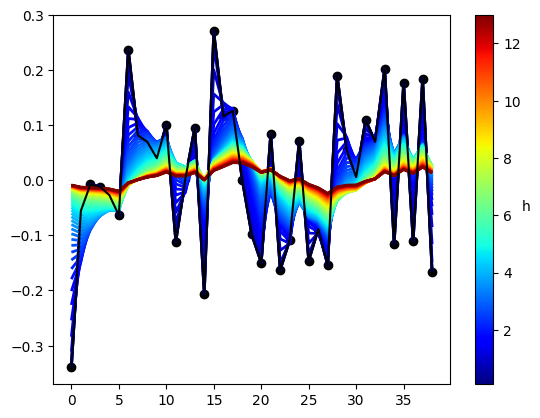

In [110]:
K = 39
z = mu[0, :, -1].float()

hs = torch.linspace(0.1, K/3, 64)
xs = []
ys = []

# since the maximum weight is on the far right side,
# we need to shift the signal by half the kernel size
# so the current timestep is also on the far right
ks = []
for i, h in enumerate(hs):
    kernel = gaussian_kernel(K, h)
    ks.append(kernel)
    z_pad = F.pad(z.roll((K-1)//2).view(1, 1, z.size(-1)), ((K-1)//2, (K-1)//2), "circular")
    y = F.conv1d(z_pad, kernel.flip(dims=[0]).view(1, 1, K)).squeeze()
    x = torch.arange(z.size(-1))
    xs.append(x)
    ys.append(y)
    
lc = multiline(xs, ys, hs, cmap='jet', lw=2)
cbar = plt.colorbar(lc)
cbar.set_label("h", rotation=0)

plt.plot(torch.arange(z.size(-1)), z, c="black")
plt.scatter(torch.arange(z.size(-1)), z, label="z", c="black")

plt.show()

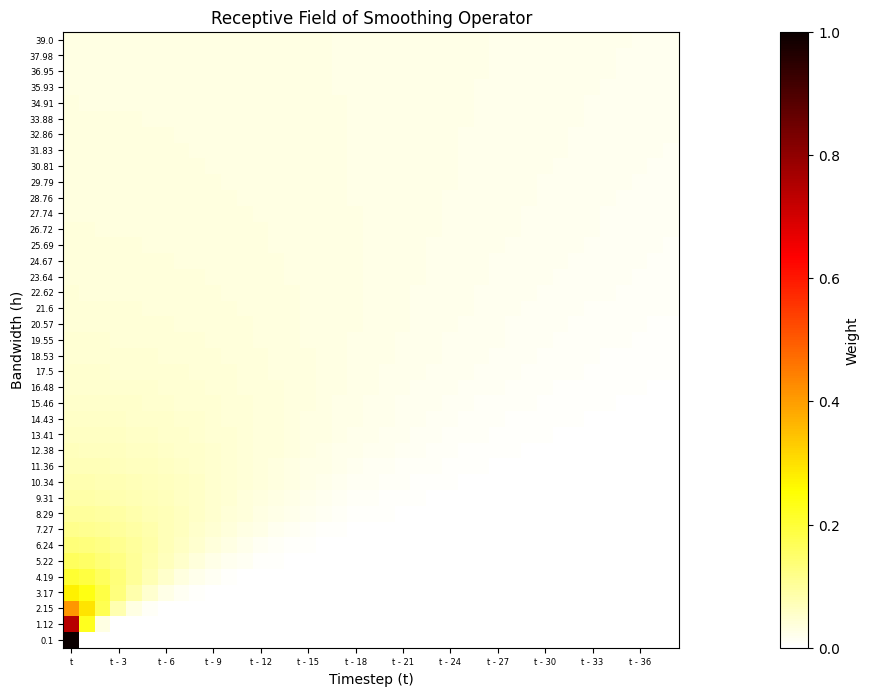

In [111]:
K = 39
ks = []
hs = torch.linspace(0.1, K, 39)
for i, h in enumerate(hs):
    kernel = gaussian_kernel(K, h)
    ks.append(kernel)
ks = np.array(ks)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 8), width_ratios=[0.96, 0.04])
im = ax1.imshow(ks, origin="lower", aspect="equal", interpolation="none", cmap="hot_r")
cbar = fig.colorbar(im, cax=ax2, orientation="vertical")
cbar.set_label("Weight")
ax1.set_xlabel("Timestep (t)")
ax1.set_ylabel("Bandwidth (h)")
ax1.set_xticks(np.arange(0, 39, 3), [f"t{f' - {t}' if t > 0 else ''}" for t in np.arange(0, 39, 3)], fontsize=6)
ax1.set_yticks(np.arange(39), hs.numpy().round(2), fontsize=6)
ax1.set_title("Receptive Field of Smoothing Operator")
plt.show()

Now auto-regressively, with a truncated kernel when timesteps are not available.

In [112]:
z.shape

torch.Size([39])

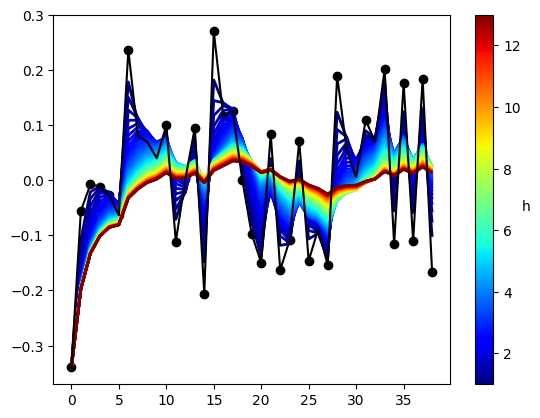

In [113]:
K = 39
z = mu[0, :, -1].float()

hs = torch.linspace(1.0, K/3, 64)
xs = []
ys = []

for i, h in enumerate(hs):
    T = z.size(-1)
    x = torch.arange(z.size(-1))
    y = torch.stack([
        (z[:t] * gaussian_kernel(t, h).flip(dims=[0])).sum()
        for t in range(1, T+1)
    ], dim=0)
    xs.append(x)
    ys.append(y)

lc = multiline(xs, ys, hs, cmap='jet', lw=2)
cbar = plt.colorbar(lc)
cbar.set_label("h", rotation=0)

plt.plot(torch.arange(z.size(-1)), z, c="black")
plt.scatter(torch.arange(z.size(-1)), z, label="z", c="black")

plt.show()

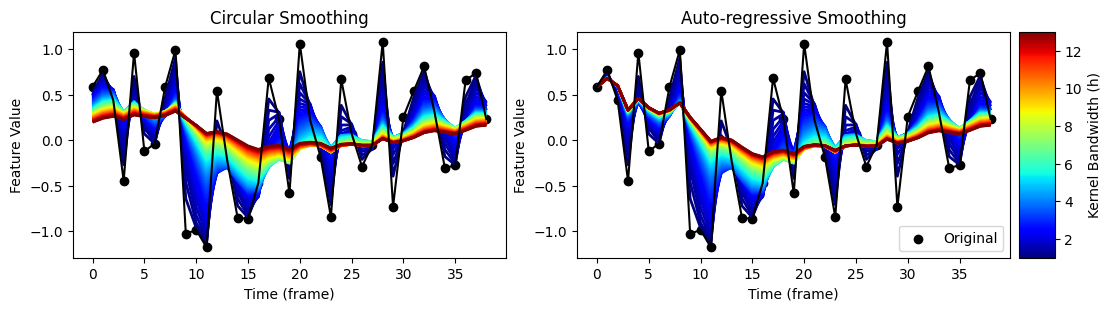

In [114]:
K = 39
z = mu[0, :, 2].float()
hs = torch.linspace(1.0, K/3, 64)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(11, 3), width_ratios=[0.48, 0.48, 0.04], constrained_layout=True)

xs = []
ys = []

# since the maximum weight is on the far right side,
# we need to shift the signal by half the kernel size
# so the current timestep is also on the far right
for i, h in enumerate(hs):
    kernel = gaussian_kernel(K, h).flip(dims=[0]).view(1, 1, K)
    z_pad = F.pad(z.roll((K-1)//2).view(1, 1, z.size(-1)), ((K-1)//2, (K-1)//2), "circular")
    y = F.conv1d(z_pad, kernel).squeeze()
    x = torch.arange(z.size(-1))
    xs.append(x)
    ys.append(y)
    
lc = multiline(xs, ys, hs, ax=ax1, cmap='jet', lw=2)
ax1.plot(torch.arange(z.size(-1)), z, c="black")
ax1.scatter(torch.arange(z.size(-1)), z, c="black")
ax1.set_title("Circular Smoothing")
ax1.set_ylabel("Feature Value")
ax1.set_xlabel("Time (frame)")


xs = []
ys = []

for i, h in enumerate(hs):
    T = z.size(-1)
    x = torch.arange(z.size(-1))
    y = torch.stack([
        (z[:t] * gaussian_kernel(t, h).flip(dims=[0])).sum()
        for t in range(1, T+1)
    ], dim=0)
    xs.append(x)
    ys.append(y)

lc = multiline(xs, ys, hs, ax=ax2, cmap='jet', lw=2)
cbar = plt.colorbar(lc, cax=ax3)
cbar.set_label("Kernel Bandwidth (h)")
ax2.plot(torch.arange(z.size(-1)), z, c="black")
ax2.scatter(torch.arange(z.size(-1)), z, label="Original", c="black")
ax2.set_title("Auto-regressive Smoothing")
ax2.set_ylabel("Feature Value")
ax2.set_xlabel("Time (frame)")

ax2.legend(loc="lower right")
plt.show()

Vectorised implementation to apply at training time:

1. Build kernels for each timestep and stack along a dimension
2. Pass a vector of bandwidths
3. Apply forward operator using a torch module

In [187]:
h = torch.linspace(0.01, 39/3, 64)
k = torch.arange(39).view(39, 1)
w = torch.exp(-(k.pow(2)) / (2 * h.pow(2)))
w /= w.sum(axis=0)

# im = plt.imshow(w[0].t(), origin="lower")
# plt.colorbar(im)
# plt.show()



tensor([6.4674e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.4013e-45, 1.2717e-38, 4.4510e-32,
        3.7093e-26, 7.3599e-21, 3.4771e-16, 3.9112e-12, 1.0475e-08, 6.6798e-06,
        1.0142e-03, 3.6664e-02, 3.1558e-01])

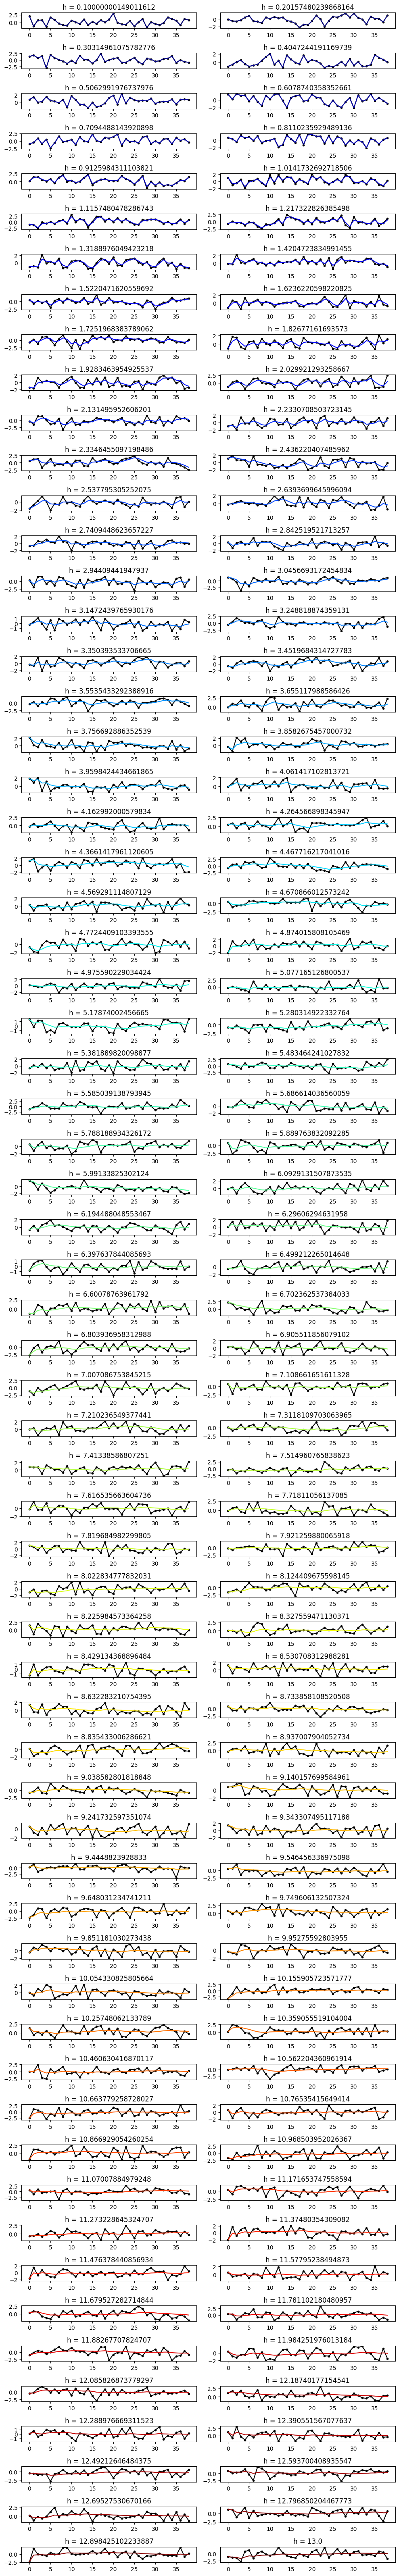

In [531]:
from torch import testing as tt

class GaussianKernelSmoothing(torch.nn.Module):
    def forward(self, x: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        return torch.cat([
            (x[:, :t] * self.gaussian_kernel(t, h, x.device)).sum(dim=1, keepdims=True)
            for t in range(1, x.size(1) + 1)
        ], dim=1)

    @staticmethod
    def gaussian_kernel(K: int, h: torch.Tensor, device: str = "cpu"):
        k = torch.arange(1, K + 1, dtype=torch.float32, device=device).view(1, K, 1)
        w = torch.exp(-(k.pow(2)) / (2 * h.pow(2)))
        return (w / w.sum(dim=1, keepdims=True)).flip(dims=[1])

def gaussian_kernel_smoothing(x: torch.Tensor, h: torch.Tensor):
    ys = []
    for i in range(len(x)):
        yis = []
        for j in range(len(h)):
            T = x.size(1)
            yids = []
            for t in range(1, T + 1):
                k = torch.arange(1, t+1)
                w = torch.exp(-(k ** 2) / (2 * h[j] ** 2))
                w = (w / w.sum()).flip(dims=[0])
                y = (x[i, :t, j] * w).sum()
                yids.append(y)
            y = torch.stack(yids)
            yis.append(y)
        ys.append(torch.stack(yis, dim=-1))
    return torch.stack(ys, dim=0)

def test_gaussian_kernel_smoothing(seq_len: int = 5, embedding_dim: int = 10):
    num_samples = 1
    seq_len = 39
    embedding_dim = 128
    
    # generate some random data
    x = torch.randn(num_samples, seq_len, embedding_dim)
    # bandwidth different for each dimension, 0.1 bandwidth applies no smoothing
    h = torch.linspace(0.1, seq_len/3, embedding_dim)
    # calculate manually
    expected = gaussian_kernel_smoothing(x, h)

    # check vectorised implementation
    kernel = GaussianKernelSmoothing()
    actual = kernel(x, h)

    tt.assert_close(expected, actual)

    return x, h, actual

xs, hs, ys = test_gaussian_kernel_smoothing()

fig, axes = plt.subplots(nrows=xs.size(-1) // 2, ncols=2, figsize=(10, 64))
colors = plt.cm.jet(np.linspace(0, 1, hs.size(0)))

for j, ax in zip(range(xs.size(-1)), axes.flatten()):
    x = torch.arange(xs.size(1))
    y = ys[:, :, j].squeeze()

    ax.plot(x, xs[:, :, j].squeeze(), c="black")
    ax.scatter(x, xs[:, :, j].squeeze(), label="Original", c="black", marker='.')
    ax.plot(x, y, c=colors[j])
    ax.set_title(f"h = {hs[j]}")

plt.tight_layout()
plt.show()